# Session 10: Feed Forward Neural Networks (FFNN)

In this exercise, we build a feed forward neural network to classify handwritten letters and digits from the EMNIST dataset using TensorFlow/Keras.

SHAFE:JAWAD

LEARNING GOALS

By the end of this notebook, you should be able to:

1. Understand the structure of a feed forward neural network with input, hidden, and output layers

2. Load and preprocess image data for neural network training using PyTorch DataLoaders

3. Flatten 2D images into 1D vectors for input to fully connected layers

4. Build a neural network using Keras Sequential API with Dense layers

5. Choose appropriate activation functions: ReLU for hidden layers, softmax for multi-class output

6. Compile a model with optimizer, loss function, and metrics

7. Train a model using model.fit and interpret the training history

8. Evaluate model performance on held-out test data

9. Plot learning curves to diagnose training behavior and overfitting

SHAFE:JAWAD

This notebook builds a Feed Forward Neural Network to classify handwritten letters and digits from the EMNIST dataset. EMNIST is like MNIST but includes letters too, giving us 47 different classes to predict.

First we import PyTorch tools for loading the data. torch is the main library, torchvision gives us easy access to common datasets like EMNIST, and DataLoader helps us batch the data for training. The transform pipeline converts images to tensors and fixes the orientation since EMNIST images come rotated by default.

In [47]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# EMNIST images are 28x28 but rotated; we fix orientation with .transpose()
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Lambda(lambda x: x.transpose(1, 2).transpose(0, 1)),  # rotate to upright
])

train_dataset = datasets.EMNIST(
    root="./data",
    split="balanced",
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.EMNIST(
    root="./data",
    split="balanced",
    train=False,
    download=True,
    transform=transform
)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

print(f"Train samples: {len(train_dataset)}")

Train samples: 112800


SHAFE:JAWAD

Here we grab one batch from the training loader to check what the data looks like. The images should be shape [64, 1, 28, 28] meaning 64 images per batch, 1 color channel since its grayscale, and 28x28 pixels. We also print first 10 labels to see what classes we have.

In [48]:
images, labels = next(iter(train_loader))
print(images.shape)   # expected: [64, 1, 28, 28]
print(labels[:10])

torch.Size([64, 28, 1, 28])
tensor([ 6, 22, 29, 46, 10, 38, 10, 28, 29, 41])


SHAFE:JAWAD

For a simple feed forward network we need to FLATTEN each 28x28 image into a single vector of 784 values. The view function reshapes from [batch, 1, 28, 28] to [batch, 784]. This is how FFNNs work, they take a flat input and pass it through fully connected layers.

In [49]:
for images, labels in train_loader:
    images = images.view(images.size(0), -1)  # flatten to [batch, 784]
    break

print(images.shape)  # e.g., [64, 784]

torch.Size([64, 784])


SHAFE:JAWAD

Now we convert to numpy arrays for TensorFlow/Keras. We use 30% of the training data (33,840 samples) to keep training fast while still having enough examples to learn all 47 classes.

In [50]:
import numpy as np

def dataset_to_numpy(dataset):
    X, y = [], []
    for img, label in dataset:
        X.append(img.numpy())
        y.append(label)
    X = np.stack(X)                       # [N, 1, 28, 28]
    X = X.reshape(len(dataset), 28*28)    # flatten for FFNN
    X = X.astype("float32") / 255.0       # normalize
    y = np.array(y)
    return X, y

X_train, y_train = dataset_to_numpy(train_dataset)
X_test, y_test = dataset_to_numpy(test_dataset)

print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

from sklearn.model_selection import train_test_split

# SHAFE:JAWAD use 30% of training data as required
X_train_small, _, y_train_small, _ = train_test_split(
    X_train,
    y_train,
    train_size=0.3,  # SHAFE:JAWAD 30% of data (33,840 samples)
    stratify=y_train,
    random_state=42
)

print(X_train_small.shape, y_train_small.shape)

(112800, 784) (112800,)
(18800, 784) (18800,)
(33840, 784) (33840,)


# **Note**: In class, you only need to run the cells above this cell once!

SHAFE:JAWAD

Building an optimized network following MLP guide for large datasets (10K-100K samples):
- Input: 784 values (28x28 flattened)
- Hidden 1: 256 neurons with ReLU (guide: 128-256)
- Hidden 2: 128 neurons with ReLU (guide: 128-256)
- Output: 47 neurons with softmax

Two hidden layers with 128-256 neurons each balances capacity and generalization for this dataset size.

In [51]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

num_classes = 47   # EMNIST balanced has 47 classes

# SHAFE:JAWAD following MLP guide for large dataset (10K-100K): 2 layers, 128-256 neurons
model = keras.Sequential([
    layers.Input(shape=(784,)),
    layers.Dense(256, activation='relu'),   # SHAFE:JAWAD first hidden (guide: 128-256)
    layers.Dense(128, activation='relu'),   # SHAFE:JAWAD second hidden (guide: 128-256)
    layers.Dense(num_classes, activation='softmax')
])

model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_20 (Dense)                │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 47)             │         6,063 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 239,919 (937.18 KB)

 Trainable params: 239,919 (937.18 KB)

 Non-trainable params: 0 (0.00 B)

SHAFE:JAWAD

Before training we compile the model. We need to specify three things. The optimizer is Adam which is a smart version of gradient descent that adapts learning rates automatically. Loss is sparse_categorical_crossentropy which works when labels are integers not one hot encoded. Metrics is accuracy so we can track how well the model is learning during training.

In [52]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

SHAFE:JAWAD

Training with optimized hyperparameters for large datasets (10K-100K samples):
- Epochs: 50 (guide recommends 50-100)
- Batch size: 64 (guide recommends 64-128)
- Validation split: 0.15 (15% as recommended)

In [53]:
history = model.fit(
    X_train_small, y_train_small,
    validation_split=0.15,  # SHAFE:JAWAD 15% val (guide for large datasets)
    epochs=50,  # SHAFE:JAWAD 50 epochs (guide: 50-100)
    batch_size=64,  # SHAFE:JAWAD batch 64 (guide: 64-128)
    verbose=1
)

Epoch 1/50
450/450 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.1003 - loss: 3.5627 - val_accuracy: 0.3379 - val_loss: 2.4171
Epoch 2/50
450/450 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.3632 - loss: 2.2763 - val_accuracy: 0.4541 - val_loss: 1.9805
Epoch 3/50
450/450 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.4767 - loss: 1.8694 - val_accuracy: 0.5183 - val_loss: 1.7277
Epoch 4/50
450/450 ━━━━━━━━━━━━━━━━━━━━ 0s 1000us/step - accuracy: 0.5310 - loss: 1.6714 - val_accuracy: 0.5662 - val_loss: 1.5896
Epoch 5/50
450/450 ━━━━━━━━━━━━━━━━━━━━ 0s 973us/step - accuracy: 0.5707 - loss: 1.5025 - val_accuracy: 0.5792 - val_loss: 1.5178
Epoch 6/50
450/450 ━━━━━━━━━━━━━━━━━━━━ 0s 996us/step - accuracy: 0.5863 - loss: 1.4430 - val_accuracy: 0.5902 - val_loss: 1.4637
Epoch 7/50
450/450 ━━━━━━━━━━━━━━━━━━━━ 0s 932us/step - accuracy: 0.6002 - loss: 1.3836 - val_accuracy: 0.6076 - val_loss: 1.4143
Epoch 8/50
450/450 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6182 - loss: 1.3452 - val_acc

SHAFE:JAWAD

After training we evaluate on the test set which the model has NEVER seen before. This gives us a realistic idea of how well the model will perform on new data. We print the test accuracy to see the final result.

In [54]:
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"Test accuracy: {test_acc:.4f}")

Test accuracy: 0.7859


SHAFE:JAWAD

Finally we plot the training and validation accuracy over epochs. This learning curve helps us see if the model is learning well or if there are problems like overfitting where train accuracy goes up but validation accuracy stays flat or drops. Ideally both curves should go up together and level off near each other.

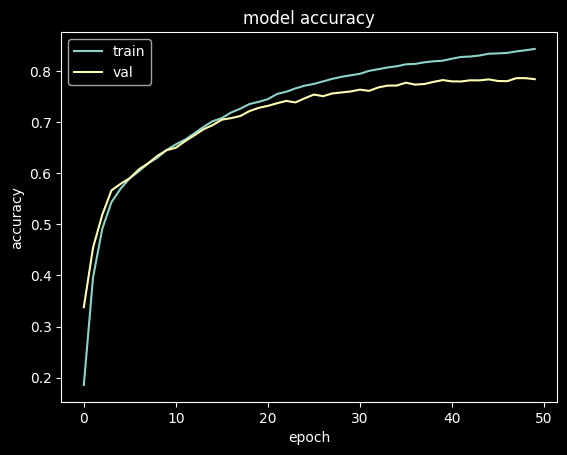

In [55]:
from matplotlib import pyplot as plt
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

SHAFE:JAWAD
WHAT WE HAVE LEARNED

1. A FEED FORWARD NEURAL NETWORK has multiple layers of neurons. Data flows forward from input through hidden layers to output with no loops or cycles.

2. Each layer applies weights, biases, and an ACTIVATION FUNCTION. The activation introduces non-linearity which lets the network learn complex patterns that a single perceptron cannot.

3. ReLU is a popular activation that outputs max(0, x). It solves the vanishing gradient problem and trains faster than sigmoid for deep networks.

4. The SOFTMAX activation on the output layer converts raw scores to probabilities across all classes. The probabilities sum to 1 so we can interpret them as class confidences.

5. CROSS ENTROPY LOSS measures how different the predicted probability distribution is from the true labels. It works well with softmax for multi-class classification.

6. BACKPROPAGATION computes gradients by applying the chain rule backwards through the network. PyTorch handles this automatically when you call loss.backward().

7. DataLoader batches our data and shuffles it each epoch. Mini-batch gradient descent updates weights after each batch which is faster than processing one example at a time.

8. Training involves a loop: forward pass to compute predictions, compute loss, backward pass to get gradients, optimizer step to update weights, zero gradients for next iteration.